# Instalar dependencias

In [1]:
!pip install git+https://github.com/facebookresearch/segment-anything.git
!pip install opencv-python matplotlib supervision
!pip install torch torchvision
!pip install pycocotools

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-__kn9grc
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-__kn9grc
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=f336bd21aed5482fc51e45cb0d5d65dda08cbfa772af7c625d110f7699d471de
  Stored in directory: /tmp/pip-ephem-wheel-cache-psw0igil/wheels/29/82/ff/04e2be9805a1cb48bec0b85b5a6da6b63f647645750a0e42d4
Successfully built segment_anything
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.8 MB/s eta 0:00:00


# Descargar modelo SAM

In [2]:
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2026-05-23 21:20:54--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 54.230.79.122, 54.230.79.93, 54.230.79.88, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|54.230.79.122|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M  13.1MB/s    in 5.6s    

2026-05-23 21:21:00 (63.8 MB/s) - ‘sam_vit_b_01ec64.pth’ saved [375042383/375042383]



# Importaciones

In [3]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

#Configurar modelo

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry["vit_b"](
    checkpoint="sam_vit_b_01ec64.pth"
)

sam.to(device=DEVICE)

mask_generator = SamAutomaticMaskGenerator(sam)
predictor = SamPredictor(sam)

# Cargar imágenes

In [5]:
from google.colab import files

uploaded = files.upload()

Saving input_images.zip to input_images.zip


In [6]:
import zipfile
import os

zip_path = "input_images.zip"

extract_path = "input_images"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Imágenes extraídas correctamente")

Imágenes extraídas correctamente


In [9]:
import os

os.listdir("input_images")

['input_images']

In [15]:
input_folder = "input_images/input_images"
output_folder = "output_visualizations"

os.makedirs(output_folder, exist_ok=True)

valid_extensions = (".jpg", ".jpeg", ".png")

image_files = [
    f for f in os.listdir(input_folder)
    if f.lower().endswith(valid_extensions)
]

print("Imágenes encontradas:")
print(image_files)

for file in image_files:

    image_path = os.path.join(input_folder, file)

    image = cv2.imread(image_path)

    # Verificar si la imagen se cargó correctamente
    if image is None:
        print(f"Error cargando: {file}")
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # REDUCIR TAMAÑO
    max_size = 800

    h, w = image.shape[:2]

    scale = max_size / max(h, w)

    if scale < 1:
        image = cv2.resize(
            image,
            (int(w * scale), int(h * scale))
        )

    masks = mask_generator.generate(image)

    plt.figure(figsize=(10,10))
    plt.imshow(image)

    for mask in masks:

        color = np.random.random(3)

        segmentation = mask['segmentation']

        colored_mask = np.zeros(
            (segmentation.shape[0], segmentation.shape[1], 3)
        )

        for i in range(3):
            colored_mask[:, :, i] = segmentation * color[i]

        plt.imshow(
            np.dstack((colored_mask, segmentation * 0.5))
        )

    plt.axis('off')

    save_path = os.path.join(
        output_folder,
        f"seg_{file}"
    )

    plt.savefig(save_path, bbox_inches='tight')
    plt.close()

    print(f"Procesada correctamente: {file}")

Imágenes encontradas:
['imagen9.jpg', 'imagen4.jpg', 'imagen7.jpg', 'imagen8.jpg', 'imagen5.jpg', 'imagen10.jpg', 'imagen1.jpg', 'imagen2.jpg', 'imagen6.jpg', 'imagen3.jpg']
Procesada correctamente: imagen9.jpg
Procesada correctamente: imagen4.jpg
Procesada correctamente: imagen7.jpg
Procesada correctamente: imagen8.jpg
Procesada correctamente: imagen5.jpg
Procesada correctamente: imagen10.jpg
Procesada correctamente: imagen1.jpg
Procesada correctamente: imagen2.jpg
Procesada correctamente: imagen6.jpg
Procesada correctamente: imagen3.jpg


# Guardar máscaras binarias

In [16]:
mask_output = "output_masks"

os.makedirs(mask_output, exist_ok=True)

for idx, mask in enumerate(masks):

    binary_mask = mask['segmentation'].astype(np.uint8) * 255

    cv2.imwrite(
        os.path.join(mask_output, f"mask_{idx}.png"),
        binary_mask
    )

# Segmentación interactiva

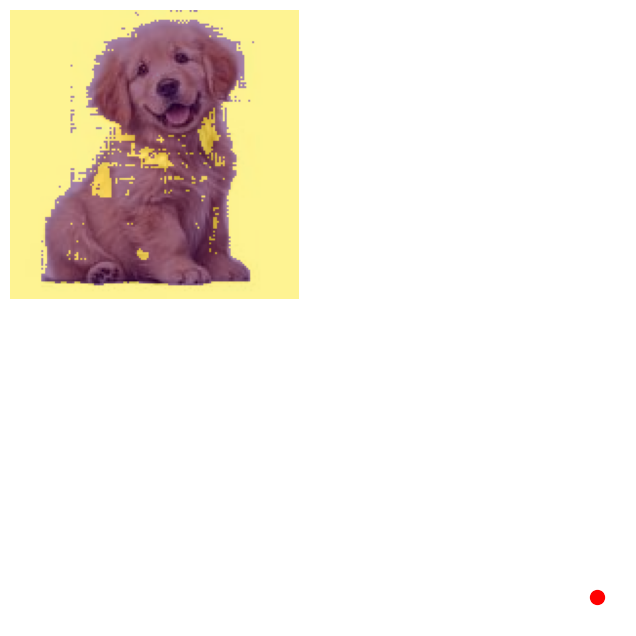

In [18]:
image = cv2.imread("input_images/input_images/imagen1.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

predictor.set_image(image)

input_point = np.array([[300, 300]])
input_label = np.array([1])

masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True
)

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.imshow(masks[0], alpha=0.5)
plt.scatter([300], [300], color='red', s=100)
plt.axis('off')
plt.show()

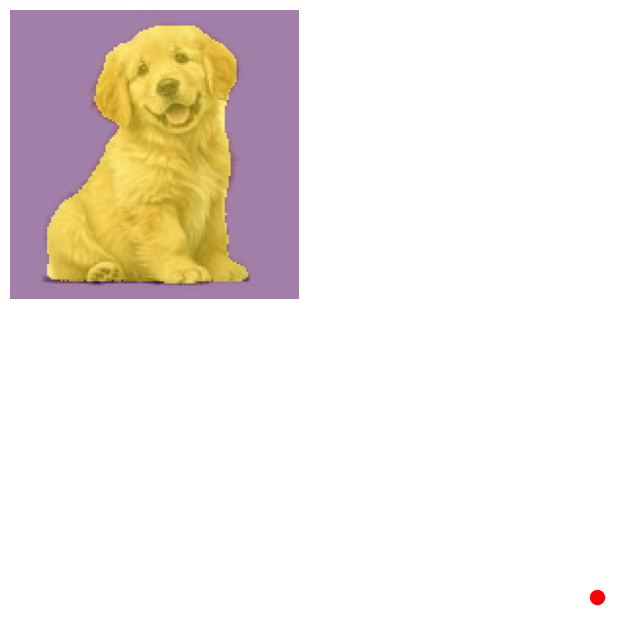

In [27]:
image = cv2.imread("input_images/input_images/imagen1.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

predictor.set_image(image)

input_point = np.array([[50, 50]])
input_label = np.array([1])

masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True
)

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.imshow(masks[0], alpha=0.5)
plt.scatter([300], [300], color='red', s=100)
plt.axis('off')
plt.show()

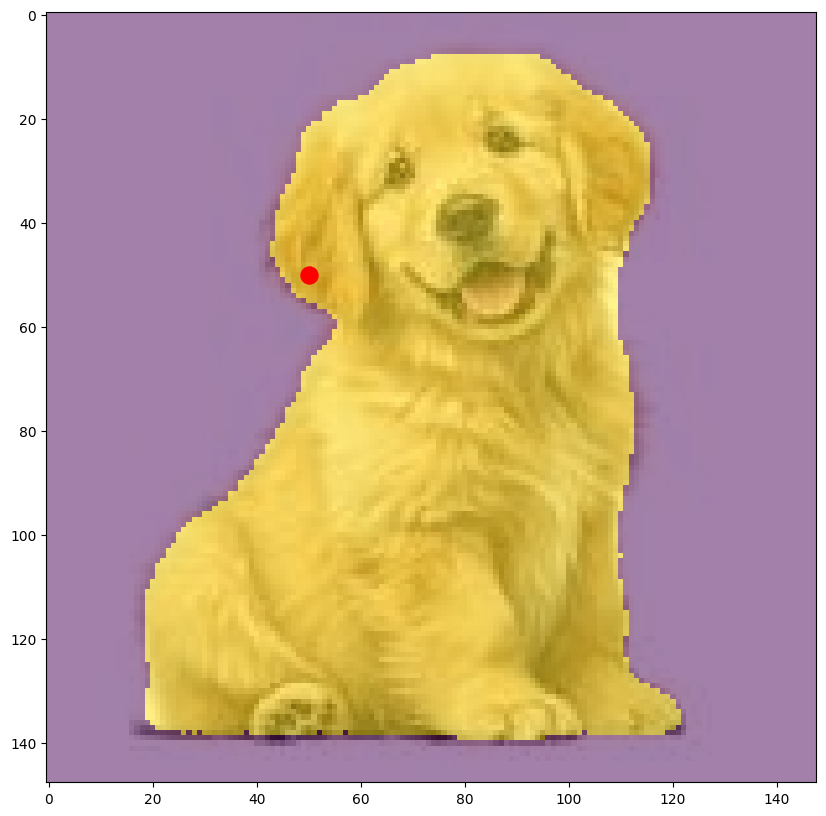

In [26]:
image = cv2.imread("input_images/input_images/imagen1.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

predictor.set_image(image)

# CAMBIA ESTAS COORDENADAS
input_point = np.array([[50, 50]])

input_label = np.array([1])

masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True
)

plt.figure(figsize=(10,10))

plt.imshow(image)

# Mostrar máscara
plt.imshow(masks[0], alpha=0.5)

# Mostrar punto seleccionado
plt.scatter(
    input_point[:,0],
    input_point[:,1],
    color='red',
    s=150
)

plt.axis('on')

plt.show()

# Métricas de segmentación

In [19]:
import pandas as pd

metrics = []

for idx, mask in enumerate(masks):

    binary = mask.astype(np.uint8)

    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    area = np.sum(binary)

    perimeter = 0

    for cnt in contours:
        perimeter += cv2.arcLength(cnt, True)

    M = cv2.moments(binary)

    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
    else:
        cx, cy = 0, 0

    metrics.append({
        "mask_id": idx,
        "area": area,
        "perimeter": perimeter,
        "centroid_x": cx,
        "centroid_y": cy
    })

df = pd.DataFrame(metrics)

df

,mask_id,area,perimeter,centroid_x,centroid_y
0,0,12160,592.142135,73,69
1,1,11798,586.828427,73,66
2,2,1690,428.953318,44,133


# Exportar métricas

In [22]:
import os

os.makedirs("metrics", exist_ok=True)

In [23]:
df.to_csv("metrics/segmentation_metrics.csv", index=False)

print("Métricas guardadas correctamente")

Métricas guardadas correctamente


In [28]:
import pandas as pd

df = pd.read_csv("metrics/segmentation_metrics.csv")

df.head()

,mask_id,area,perimeter,centroid_x,centroid_y
0,0,12160,592.142135,73,69
1,1,11798,586.828427,73,66
2,2,1690,428.953318,44,133


(np.float64(-0.5), np.float64(789.5), np.float64(789.5), np.float64(-0.5))

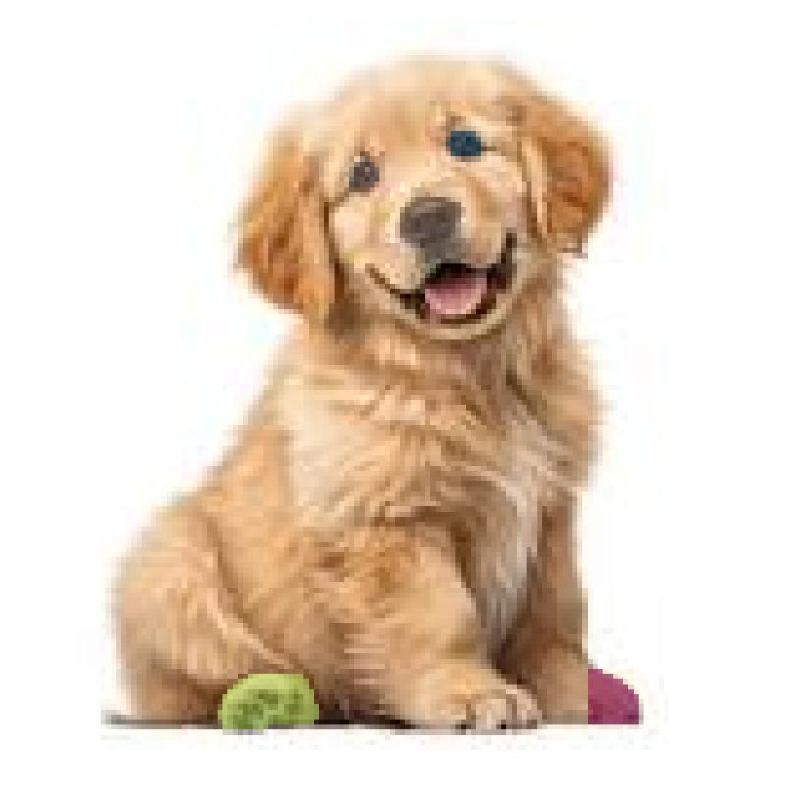

In [29]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("output_visualizations/seg_imagen1.jpg")

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis("off")

(np.float64(-0.5), np.float64(274.5), np.float64(182.5), np.float64(-0.5))

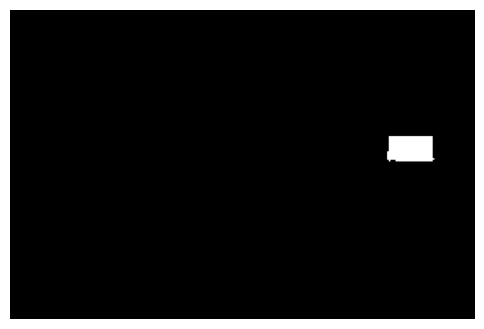

In [30]:
mask = Image.open("output_masks/mask_0.png")

plt.figure(figsize=(6,6))
plt.imshow(mask, cmap="gray")
plt.axis("off")